# Inspection of dataset collections provided in WP2-ICDR-O3-LP-v2

@Rory Pre-amble - Tell the reviewers what this is and what it's for. This is for the new reviewers as we do have staff changes regularly

### Setup
First we import the necessary libraries and set a few parameters based on the Delivery Note information (in this case, provided in COPCO-1060)

In [1]:
#if your cell keeps throwing import errors, run the following pip installs to get the correct libraries in place.
# uncomment if needed.
# !pip install cartopy
# !pip install cdsapi
# !pip install xarray
# !pip install matplotlib

import xarray as xr
import matplotlib.pyplot as plt
import os
import cartopy
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib as mpl
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import datetime
import cdsapi
import zipfile
import pandas as pd
import requests
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from IPython.display import display


In [2]:

# Data collection details - each parameter will encompass a different data collection.
# set product parameters in a python dictionary. adjust for future versions / additional products

product_parameters = {
    'OSIRIS': {
        'sensor_line'         : 'LP',
        'satellite'           : 'ODIN',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'OSIRIS', # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',    # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0003',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/12/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/11/2001'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'ACE': {
        'sensor_line'         : 'LP',
        'satellite'           : 'SCISAT',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'ACE', # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',    # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0003',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/12/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/02/2004'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'MLS': {
        'sensor_line'         : 'LP',
        'satellite'           : 'AURA',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'MLS',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0003',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/08/2004'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_mixing_ratio'],
        'height_variable'     : 'pressure' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'SABER': {
        'sensor_line'         : 'LP',
        'satellite'           : 'TIMED',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'SABER',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0002',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/01/2002'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_mixing_ratio'],
        'height_variable'     : 'pressure' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'SAGE-III': {
        'sensor_line'         : 'LP',
        'satellite'           : 'ISS',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'SAGE_III',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0002',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/09/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/06/2017'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'OMPS-SASK': {
        'sensor_line'         : 'LP',
        'satellite'           : 'NPP',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'OMPS',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'USASK',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0003',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/02/2012'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'OMPS-UBR': {
        'sensor_line'         : 'LP',
        'satellite'           : 'NPP',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'OMPS',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'UBR',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0002',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/02/2012'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'ANOM_MZM': {
        'sensor_line'         : 'LP',
        'satellite'           : 'MERGED',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'ANOM_MZM',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0010',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/10/1984'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['merged_ozone_anomaly'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'CONC_MZM': {
        'sensor_line'         : 'LP',
        'satellite'           : 'MERGED',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'CONC_MZM',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0010',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/10/1984'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['merged_ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
    'CONC_LLG': {
        'sensor_line'         : 'LP',
        'satellite'           : 'MERGED',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'CONC_LLG',    # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',      # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0006',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/11/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/10/2001'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['merged_ozone_concentration'],
        'height_variable'     : 'altitude' # name of the height variable in the dataset. needed for plotting. if not set, will default to 'altitude'
    },
}

Now we fix the path for the manifest files and select which product from the list above we will work with.
We also set the path for the directory where the dataset files will be stored locally. It will be created if it doesn't exist.
There are a few True/False switches with options: 
 - Set "download_full_dataset" if you wish to verify not just the data delivery but the full data collection. It may be useful for context, but it may also imply the download of a huge amount of data - so use with caution. 
 - "download_delivery" is basically the same, but for the files contained in the delivery; in general this will need to remain "True"; an addtional check is added later and only files that are not on your disk already will be downloaded. 
 - "clean_workdir" will clean the specified directory *before* we start working. May be useful in the case of a re-inspection. 

In [3]:
# Delivery settings

manifest_file = 'https://wdc.dlr.de/C3S_312b_Lot2/manifest_C3S_312b_Lot2_O3_MONTHLY_2026-02-27.txt'

product = 'OSIRIS' # change this to the product name above to cycle through the various data collections delivered.
sensor_line         = product_parameters[product]['sensor_line']
satellite           = product_parameters[product]['satellite']
instrument          = product_parameters[product]['instrument']
algorithm           = product_parameters[product]['algorithm']
version             = product_parameters[product]['version']
delivery_start      = product_parameters[product]['delivery_start']
delivery_end        = product_parameters[product]['delivery_end']
collection_start    = product_parameters[product]['collection_start']
collection_end      = product_parameters[product]['collection_end']
temporal_resolution = product_parameters[product]['temporal_resolution']
parameter_list      = product_parameters[product]['parameter_list']
height_variable     = product_parameters[product]['height_variable']

# options for download
download_full_dataset = True # download full CDR or not
download_delivery     = True # download files for this delivery
# directory where we will store the datasets
work_dir = f'/Users/cxjo/Documents/Datasets/Ozone/{product}/'
clean_workdir = False        # set if we should delete all the files in the work dir before we start or not

if not os.path.exists(work_dir):
    print(work_dir)
    os.makedirs(work_dir)

if (clean_workdir):
    os.remove(f'{work_dir}/*') # clean directory before we start working (if desired)

### Download manifest file and get list of file URLs to download corresponding to the delivery

In [4]:
# Download manifest file and get list of file URLs to download corresponding to the delivery
local_manif_fname = os.path.basename(manifest_file)
r = requests.get(manifest_file)
with open(local_manif_fname, 'w') as file:
    file.write(r.text)

# now read the manifest file and print the lines corresponding to the satellite and instrument of interest
# UNCOMMENT if you need to inpect the pattern of the path of each line in the manifest file

# with open(local_manif_fname,'r') as file:
#     for line in file:
#         if satellite in line and instrument in line and version in line and algorithm in line and sensor_line in line:
#             print(line)



First we define a function that will read the local copy of the manifest file and identify the lines corresponding to the data we are interested in.
We provide start and end dates, a frequency and the parameters defined in the beginning of the script that are unique to the dataset we are inspecting.
It will store the missing files into a list and print that list.
NOTE: We need to be very careful with the file pattern, as it might change for each collection.
It will return a list of existing files that will be useful below.
Then we call that function specifying the delivery dates as start and end dates.

In [8]:
def check_files_in_manifest(date_start, date_end, temporal_resolution,sensor_line,satellite, instrument, algorithm, version, manifest_file, mode='delivery'):
    """
    Inputs: Date_Start, date_end, temporal_resolution (all directly from the delivery note); satellite, instrument, algorithm, version (deduced from the delivery note and product documentation); manifest_fle (from delivery note)
    Outputs: existing_files a list of file dates, in string format of actual files delivered and verified.
    Function: checks the list of files reported in the manifest, against the actual datasets in the folder, producing a list of verified and missing files, and producing an object containing a list of verified files.
    """
    # Create a date range
    date_range = pd.date_range(start=date_start, end=date_end, freq=temporal_resolution) # MS: month start frequency

    # Prepare the pattern for file names
    missing_files = []
    existing_files = []

    # Read the manifest file (assuming it's a list of filenames)
    with open(manifest_file, 'r') as f:
        manifest_files = set(f.read().splitlines())  # Assuming one filename per line

    # Loop through the date range and generate the file pattern for each month
    for date in date_range:
        # Format the date in YYYYMM
        YYYYMM = date.strftime('%Y%m')
        # carefully inspect this file pattern:
        file_pattern = f"http://wdc.dlr.de/C3S_312b_Lot2/O3/{sensor_line}/{satellite}/{instrument}/{algorithm}/{version}/L3_MONTHLY/{YYYYMM[:4]}/{YYYYMM}-C3S-L3_OZONE-O3_PRODUCTS-{instrument}-{satellite}-{algorithm}-MONTHLY-{version}.nc"
        # Check if the file is in the manifest
        if file_pattern not in manifest_files:
            missing_files.append(file_pattern)
        else:
            existing_files.append(file_pattern)
    if mode == 'delivery': 
        if missing_files:
            nmissing = len(missing_files)
            print(f"NOT all expected files are present")
            print(f"Missing files for the following {nmissing} date(s):")
            for file in missing_files:
                print(file)
        else:
            nexisting = len(existing_files)
            print(f"All {nexisting} expected dates are present in the manifest file.")
    elif mode == 'full':
        pass # just skips the printing section

    return existing_files



file_list = check_files_in_manifest(delivery_start, delivery_end, temporal_resolution,sensor_line,satellite, instrument, algorithm, version, local_manif_fname,mode='delivery')



NOT all expected files are present
Missing files for the following 1 date(s):
http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2025/202506-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc


If there are any missing files:
1) Check the submitted delivery note - have the contractors advised you the files will be absent. If not,
2) double check they are missing by pasting the link into the browser. If verified:
3) Query the contractors regarding the missing files, seeking an explanation.
4)  (i) If acceptable, add a comment asking them in the _Reviewed delivery note to update it with the information.
    (ii) If not, contact your TO.

When a resolution is found, update the "Correct date range" on the checklist with an appropriate note.


Here we download the data we need to proceed with the review.
We might wish to download only the ICDR we are inspecting, or the full CDR + ICDRs for this dataset version. Make the right options are set above.

Here, we check whether each file is downloadable - if the section runs correctly (noting any missing files from the previous cell) you write "Yes" in the downloadable files on the DRR.

In [9]:
#@Joao, this needs to focus only on the delivery note timeframe, else we are confusing issues. If one missing file is flagged above, only 1 missing file should be flagged below.

if download_delivery == True:
    for file in file_list:
        local_fname = work_dir + os.path.basename(file)
        if os.path.exists(local_fname): # if the file already exists, skip the download (useful for debugging and iterating on the notebook without having to re-download everything every time)
            print(f"Already exists: {local_fname}")
            continue
        print(f"Downloading {file}")
        with requests.get(file, stream=True) as r:
            r.raise_for_status()
            with open(local_fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

if download_full_dataset == True: # DON'T change the setting here. This means "If download_full_dataset is equal to True"
    file_list_full = check_files_in_manifest(collection_start, collection_end, temporal_resolution,sensor_line,satellite, instrument, algorithm, version, local_manif_fname, mode='full')
    #@Joao, I amended the input variables to be delivery_start and delivery_end, to make sure the notebook is focused on the review delivery note itself.
    # *** @Rory **** I have reverted your changes. This will only be done if download_full_dataset is set to True. This way maintain the option open if needed. If you don't want
    #to download the full dataset, simply set download_full_dataset to False and only the delivery files will be downloaded and checked.
    for file in file_list_full:
        local_fname = work_dir + os.path.basename(file)
        if os.path.exists(local_fname):
            print(f"Already exists: {local_fname}")
            continue
        print(f"Downloading {file}")
        with requests.get(file, stream=True) as r:
            r.raise_for_status()
            with open(local_fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)


Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202402-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202403-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202404-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202405-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202406-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202407-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202408-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202409-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc


## Dataset inspection
### Check metadata
Open a random file from the collection and display its contents and attributes (in this case last file in the list)

In [10]:

fname = work_dir + os.path.basename(file_list[-1]) # last file of the list of existing files, for example.
print(fname)
nc = xr.open_dataset(fname)
print(nc.info())


/Users/cxjo/Documents/Datasets/Ozone/OSIRIS/202511-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
xarray.Dataset {
dimensions:
	altitude = 59 ;
	latitude_centers = 18 ;

variables:
	float64 ozone_concentration(altitude, latitude_centers) ;
		ozone_concentration:units = mol m-3 ;
		ozone_concentration:standard_name = mole_concentration_of_ozone_in_air ;
		ozone_concentration:long_name = monthly zonal mean ozone concentration ;
		ozone_concentration:multiplication_factor_to_convert_to_molecules_percm3 = 6.022140857E+17 ;
		ozone_concentration:multiplication_factor_to_convert_to_DU_perkm = 2.24115E+06 ;
	float32 standard_error_of_the_mean(altitude, latitude_centers) ;
		standard_error_of_the_mean:units = % ;
		standard_error_of_the_mean:long_name = uncertainty of the monthly zonal  mean data, std/sqrt(N) ;
	float32 sample_standard_deviation(altitude, latitude_centers) ;
		sample_standard_deviation:units = % ;
		sample_standard_deviation:long_name = Sample standard deviation in 

For the interpretation of this information, please use chatGPT or equivalent and use the following prompt:
"what are the most important metadata fields that should always be present in netcdf files for geophysical / climate datasets obeying to CF conventions?"
For example, some of these datasets are missing the missing_value attribute, which may cause problems in some plotting tools / libraries.

Now lets produce visualisations of the datasets we are interested in to check the data values and whether they are as expected.

For LP, we have latitude-height cross-sections, so the visualisations here are very specific for this sensor line.

In [16]:
# list of local filenames
flist_local = [work_dir + os.path.basename(file_list[i]) for i in range(len(file_list))]
file_times = [
    pd.to_datetime(os.path.basename(f)[:6], format="%Y%m")
    for f in flist_local
]

filename_series = pd.Series(flist_local, index=file_times)

def preprocess(ds):
    filename = ds.encoding["source"]
    yyyymm = os.path.basename(filename)[:6]
    time = pd.to_datetime(yyyymm, format="%Y%m")
    return ds.expand_dims(time=[time])

ds_all = xr.open_mfdataset(
    flist_local,
    preprocess=preprocess,
    concat_dim="time",
    combine="nested"
)

date_range = pd.date_range(start=delivery_start, end=delivery_end, freq=temporal_resolution) # MS: month start frequency
ds_all = ds_all.reindex(time=date_range)
filename_series = filename_series.reindex(date_range)

# Extract arrays
ozone = ds_all[parameter_list[0]].values
lat = ds_all["latitude_centers"].values
alt = ds_all[height_variable].values
times = ds_all["time"].values
time_labels = pd.to_datetime(times).strftime("%Y-%m")

# Create figure
fig, ax = plt.subplots(figsize=(8,5))
fig.subplots_adjust(top=0.80)

# Initial frame
im = ax.imshow(
    ozone[0],
    origin="lower",
    aspect="auto",
    extent=[lat.min(), lat.max(), alt.min(), alt.max()],
    cmap="viridis"
)

cbar = plt.colorbar(im, ax=ax)
if "long_name" in ds_all[parameter_list[0]].attrs:
    long_name = ds_all[parameter_list[0]].attrs["long_name"]
else:
    print("long_name attribute not set")
    long_name = ds_all[parameter_list[0]].standard_name
units = ds_all[parameter_list[0]].units
cbar.set_label(f'{long_name}'+' / '+ f'{units}')

ax.set_xlabel("Latitude")
if "long_name" in ds_all[height_variable].attrs:
    long_name=ds_all[height_variable].attrs["long_name"]
else:
    print("long_name attribute not set")
    long_name = ds_all[height_variable].standard_name
units = ds_all[height_variable].units

ax.set_ylabel(f'{long_name}'+' / '+ f'{units}')
# invert pressure axis
if height_variable == "pressure":
    ax.invert_yaxis()
# title = ax.set_title(str(times[0]))
title = fig.suptitle("", y=0.95)

# Update function
def update(frame):
    im.set_array(ozone[frame])
    fname = filename_series.iloc[frame]
    time_str = time_labels[frame]
    if pd.notnull(fname):
        short_name = os.path.basename(fname)
        title.set_text(f"{product}\n{time_str}\n{short_name}")
    else:
        title.set_text(f"{product}\n{time_str}\n -- missing file --")
    return im, title

# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=500,
    blit=False
)

plt.close(fig)

HTML(ani.to_jshtml())

# ds_all["ozone_concentration"].hvplot.quadmesh(
#     x="latitude_centers",
#     y="altitude",
#     groupby="time",
#     cmap="viridis",
#     rasterize=True,
#     frame_width=700,
#     frame_height=400
# )


## Examine missing values and ozone distribution

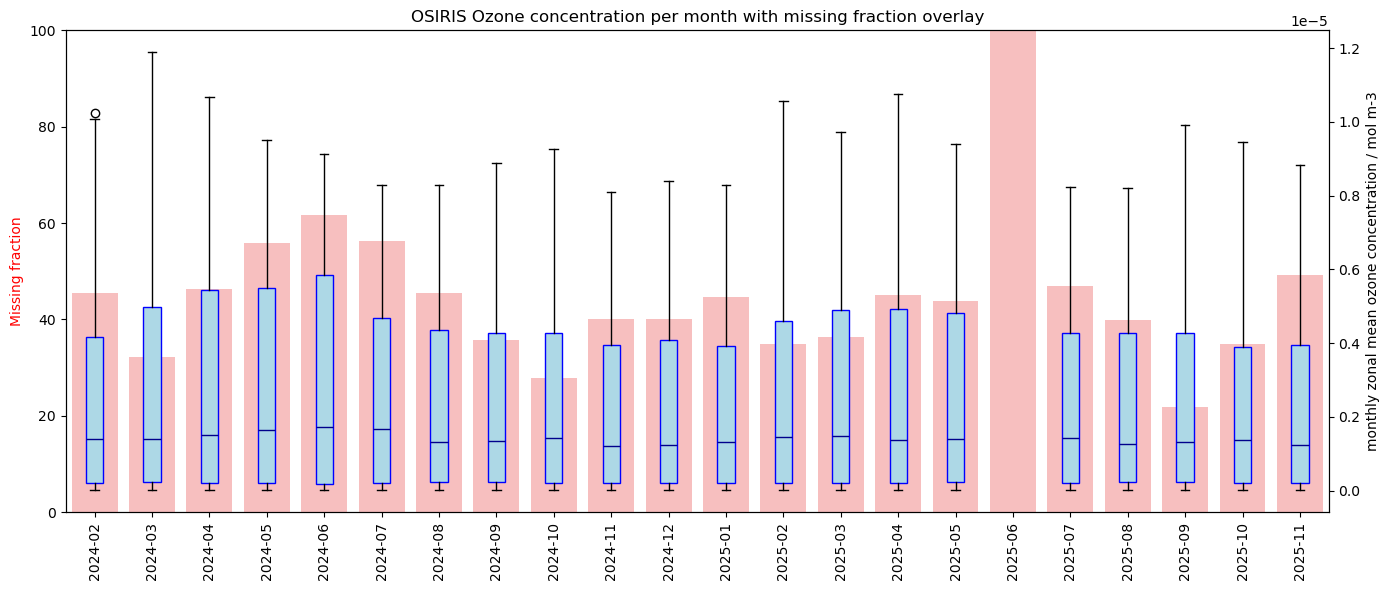

In [18]:
monthly_data = []

var_name = parameter_list[0]

for i in range(len(ds_all.time)):
    month_values = ds_all[var_name].isel(time=i).values.flatten()
    # keep only valid numbers
    month_values = month_values[~np.isnan(month_values)]
    monthly_data.append(month_values)

months = pd.to_datetime(ds_all.time.values).strftime("%Y-%m")
x_pos = np.arange(len(months))

fig, ax1 = plt.subplots(figsize=(14,6))

# Bar chart: missing fraction
# total_cells = ds_all.dims["latitude_centers"] * ds_all.dims[height_variable]
total_cells = ds_all.sizes["latitude_centers"] * ds_all.sizes[height_variable]
missing_count = ds_all[var_name].isnull().sum(dim=("latitude_centers", height_variable))
missing_fraction = missing_count / total_cells *100

ax1.bar(x_pos, missing_fraction, color="lightcoral", alpha=0.5, label="Missing fraction")
ax1.set_ylabel("Missing fraction", color="red")
ax1.set_ylim(0, 100)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(months, rotation=90)

# Boxplot: ozone concentration
ax2 = ax1.twinx()
# Only include months with data for the boxplot
valid_data = [d if len(d) > 0 else [np.nan] for d in monthly_data]
ax2.boxplot(valid_data, positions=x_pos, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="darkblue"))

if "long_name" in ds_all[parameter_list[0]].attrs:
    long_name = ds_all[parameter_list[0]].attrs["long_name"]
else:
    print("long_name attribute not set")
    long_name = ds_all[parameter_list[0]].standard_name
units = ds_all[parameter_list[0]].units

ax2.set_ylabel(f'{long_name}'+' / '+ f'{units}')
ax2.set_xticks(np.arange(len(monthly_data)))
ax2.set_xticklabels(months, rotation=90)

plt.title(f"{product} Ozone concentration per month with missing fraction overlay")
fig.tight_layout()
plt.show()

### OPTIONAL - Now we look into the full timeseries
In some cases, you will find a strange number of outliers, or a weird number of missing files. Or, when looking into the boxplots, you want to make sure if the median values make sense, considering the previous parts of the timeseries.
In this optional block of code, the full timeseries is plotted so you can inspect the full dataset and make sure the results for the data delivery you are inspecting make sense.


@JOAO - FOR REVIEWS, THIS SECTION IS REDUNDANT AS THE REVIEW FOR AN ICDR HAS NO INFLUENCE ON PREVIOUS DELIVERIES OF DATA. WE ARE ONLY SUPPOSED TO EXAMINE THE DATA COVERED BY THE DELIVERY DATES. IT WOULDNT BE ADVISABLE FOR US TO PASS COMMENTS ON PREVIOUS DELIVERIES OF DATA, EVEN IF THE GRAPHS AND INFORMATION IS SUPER INTERESTING...

/tmp/ipykernel_5198/3191393645.py:64: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_cells = ds_all.dims["latitude_centers"] * ds_all.dims[height_variable]


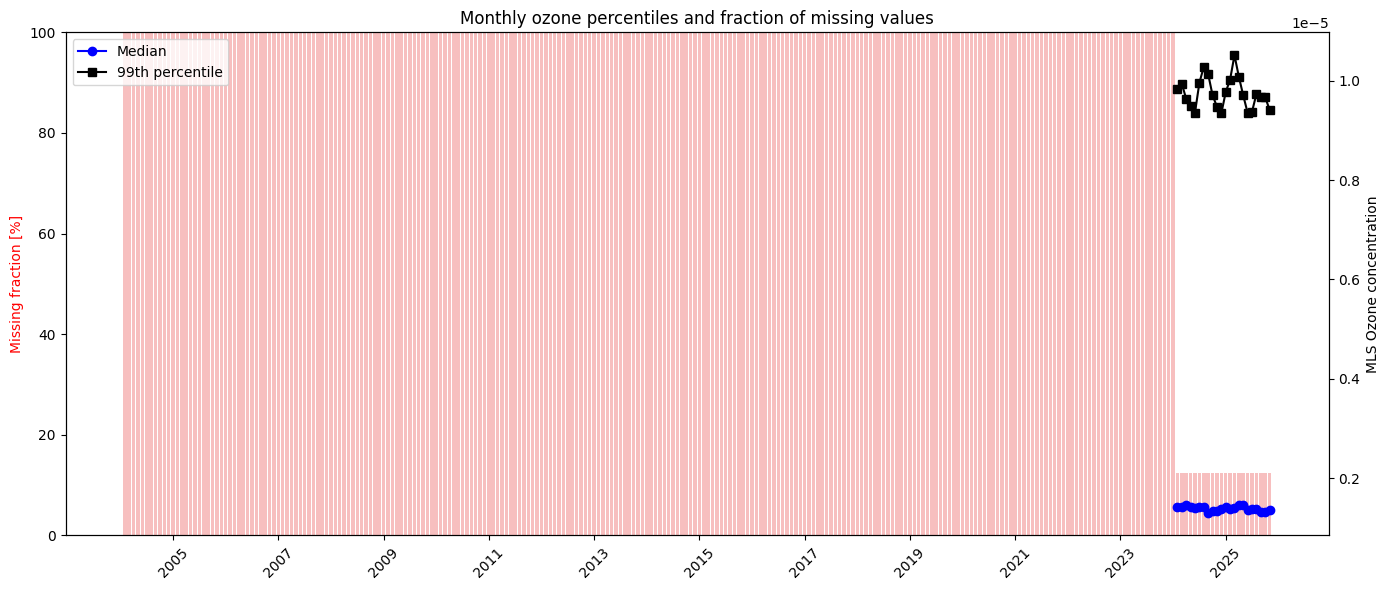

In [ ]:
if download_full_dataset == True:

flist_local_full = [work_dir + os.path.basename(file_list_full[i]) for i in range(len(file_list_full))]

def preprocess(ds):
    filename = ds.encoding["source"]
    yyyymm = os.path.basename(filename)[:6]
    time = pd.to_datetime(yyyymm, format="%Y%m")
    return ds.expand_dims(time=[time])

ds_all = xr.open_mfdataset(
    flist_local_full,
    preprocess=preprocess,
    concat_dim="time",
    combine="nested"
)

date_range = pd.date_range(start=collection_start, end=collection_end, freq=temporal_resolution) # MS: month start frequency
ds_all = ds_all.reindex(time=date_range)


monthly_data = []

for i in range(len(ds_all.time)):
    month_values = ds_all[var_name].isel(time=i).values.flatten()
    # keep only valid numbers
    month_values = month_values[~np.isnan(month_values)]
    monthly_data.append(month_values)

months = pd.to_datetime(ds_all.time.values).strftime("%Y-%m")
x_pos = np.arange(len(months))

# compute percentiles for all months in timeseries

# Percentiles to compute
pct = [50, 99]

# Store results
percentiles = {p: [] for p in pct}

# Flatten each month and compute percentiles
for i in range(len(ds_all.time)):
    month_values = ds_all[var_name].isel(time=i).values.flatten()
    month_values = month_values[~np.isnan(month_values)]  # ignore NaNs
    if len(month_values) == 0:
        # if month is fully missing, use NaN
        for p in pct:
            percentiles[p].append(np.nan)
    else:
        for p in pct:
            percentiles[p].append(np.percentile(month_values, p))

# Convert to DataFrame for convenience
df_pct = pd.DataFrame(percentiles, index=pd.to_datetime(ds_all.time.values))



# x positions (one per month)
x_pos = np.arange(len(df_pct))

fig, ax1 = plt.subplots(figsize=(14,6))

# -----------------------------
# Bar chart: missing fraction
# -----------------------------
total_cells = ds_all.dims["latitude_centers"] * ds_all.dims[height_variable]
missing_count = ds_all[var_name].isnull().sum(dim=("latitude_centers", height_variable))
missing_fraction = missing_count / total_cells * 100

ax1.bar(x_pos, missing_fraction, color="lightcoral", alpha=0.5, label="Missing fraction")
ax1.set_ylabel("Missing fraction [%]", color="red")
ax1.set_ylim(0, 100)
ax1.set_xticks(x_pos)
# Reduce X-axis labels: every other year
months = pd.to_datetime(ds_all.time.values)
xticks = months[months.month==1][::2]  # pick Jan every other year
xtick_pos = [x_pos[i] for i in range(len(months)) if months[i] in xticks]
ax1.set_xticks(xtick_pos)
ax1.set_xticklabels([d.year for d in xticks], rotation=45)

# -----------------------------
# Percentiles
# -----------------------------
ax2 = ax1.twinx()
colors = ["blue", "green", "black", "orange", "red"]

ax2.plot(x_pos, df_pct[50], marker="o", linestyle="-", color='blue', label=f"Median")
ax2.plot(x_pos, df_pct[99], marker="s", linestyle="-", color='black', label=f"{99}th percentile")

ax2.set_ylabel(f"{product} Ozone concentration")
ax2.set_title("Monthly ozone percentiles and fraction of missing values")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [11]:
#@joao, Im not clear what this section is... can you clarify?

!jupyter nbconvert --to html inspection_ozone_LP.ipynb

[NbConvertApp] WARNING | pattern 'inspection_ozone_LP.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--exe